# Engenharia de Atributos - Variáveis Categóricas

Este notebook realiza a engenharia de atributos nas variáveis categóricas do dataset, preparando os dados para o treinamento de modelos de machine learning.

**Técnicas aplicadas:**
1. **Identificação de variáveis categóricas**
2. **Análise de cardinalidade**
3. **Encoding de variáveis categóricas:**
   - Label Encoding (para variáveis binárias)
   - One-Hot Encoding (para baixa cardinalidade)
   - Target Encoding (para média cardinalidade)
   - Frequency Encoding (para alta cardinalidade)
4. **Feature Engineering de variáveis datetime**
5. **Tratamento de valores missing**
6. **Remoção de variáveis originais**
7. **Exportação dos datasets finais para treinamento**

## 0. Instalação de Bibliotecas

Instalar bibliotecas necessárias que podem não estar disponíveis por padrão.

In [3]:
# Instalar bibliotecas necessárias
!pip install -q category_encoders>=2.6.0
print("✅ Biblioteca category_encoders instalada com sucesso!")

✅ Biblioteca category_encoders instalada com sucesso!



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from category_encoders import TargetEncoder
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.6f' % x)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 1. Carregamento dos Dados

Carregando os datasets de treino e OOT (Out-of-Time) já com as transformações numéricas aplicadas.

In [5]:
# Carregar datasets
print("Carregando datasets...")

# Verificar se existem os dados transformados, senão usar os originais
try:
    df_treino = pd.read_csv('../data/processed/df_treino_transformed.csv')
    df_oot = pd.read_csv('../data/processed/df_oot.csv')
    print("✅ Datasets transformados carregados!")
except:
    df_treino = pd.read_csv('../data/processed/df_treino.csv')
    df_oot = pd.read_csv('../data/processed/df_oot.csv')
    print("✅ Datasets originais carregados!")

print(f"\n📊 Dataset de Treino:")
print(f"   - Shape: {df_treino.shape}")
print(f"   - Memória: {df_treino.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📊 Dataset OOT:")
print(f"   - Shape: {df_oot.shape}")
print(f"   - Memória: {df_oot.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📋 Primeiras linhas do treino:")
df_treino.head()

Carregando datasets...
✅ Datasets transformados carregados!

📊 Dataset de Treino:
   - Shape: (25001186, 21)
   - Memória: 24600.14 MB

📊 Dataset OOT:
   - Shape: (6250297, 21)
   - Memória: 6148.21 MB

📋 Primeiras linhas do treino:


,Timestamp,From Bank,From Account,To Bank,To Account,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,From Bank Name,Bank ID,Account Number,From Entity ID,From Entity Name,To Bank Name,Bank ID_To,Account Number_To,To Entity ID,To Entity Name
0,2022-09-01,26.531808,835A3E1E0,40.848958,835A3E1E0,5.415905,Mexican Peso,5.431333,Mexican Peso,Reinvestment,0,Mexico Bank #50,26.531808,835A3E1E0,2AA22FC6990,Corporation #126451,Mexico Bank #50,40.848958,835A3E1E0,2AA22FC6990,Corporation #126451
1,2022-09-01,30.680528,81C920DA0,49.209532,81C920DA0,7.844239,US Dollar,7.877808,US Dollar,Reinvestment,0,Flagstone Trust Bank,30.680528,81C920DA0,2AA234A1D80,Partnership #10270,Flagstone Trust Bank,49.209532,81C920DA0,2AA234A1D80,Partnership #10270
2,2022-09-01,39.972279,84346D460,69.455230,84346D460,10.259549,US Dollar,10.319281,US Dollar,Reinvestment,0,National Bank of Newbury,39.972279,84346D460,2AA20F1E430,Corporation #53588,National Bank of Newbury,69.455230,84346D460,2AA20F1E430,Corporation #53588
3,2022-09-01,23.477685,81C91D960,34.983297,81C91D960,11.242472,US Dollar,11.315431,US Dollar,Reinvestment,0,First Bank of Los Angeles,23.477685,81C91D960,2AA20AA72E0,Partnership #31123,First Bank of Los Angeles,34.983297,81C91D960,2AA20AA72E0,Partnership #31123
4,2022-09-01,27.412702,841243680,42.587073,841243680,9.838657,Swiss Franc,9.893199,Swiss Franc,Reinvestment,0,Switzerland Bank #16,27.412702,841243680,2AA233762A0,Sole Proprietorship #138109,Switzerland Bank #16,42.587073,841243680,2AA233762A0,Sole Proprietorship #138109


In [6]:
# Informações sobre os tipos de dados
print("="*80)
print("INFORMAÇÕES DOS DADOS")
print("="*80)
print("\n📊 Tipos de dados:")
print(df_treino.dtypes.value_counts())

print("\n📋 Informações detalhadas:")
df_treino.info()

INFORMAÇÕES DOS DADOS

📊 Tipos de dados:
object     14
float64     6
int64       1
Name: count, dtype: int64

📋 Informações detalhadas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25001186 entries, 0 to 25001185
Data columns (total 21 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           float64
 2   From Account        object 
 3   To Bank             float64
 4   To Account          object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
 11  From Bank Name      object 
 12  Bank ID             float64
 13  Account Number      object 
 14  From Entity ID      object 
 15  From Entity Name    object 
 16  To Bank Name        object 
 17  Bank ID_To          float64
 18  Account Number_To   object 
 19  To Entity ID        object 
 20  To Entity Name    

## 2. Identificação de Variáveis Categóricas

Identificando todas as variáveis categóricas (object e datetime) no dataset.

In [7]:
# Identificar variáveis por tipo
numeric_cols = df_treino.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_treino.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df_treino.select_dtypes(include=['datetime64']).columns.tolist()

# Tentar converter colunas que podem ser datetime
for col in categorical_cols.copy():  # Use copy() to avoid modifying during iteration
    if 'date' in col.lower() or 'time' in col.lower() or 'timestamp' in col.lower():
        try:
            df_treino[col] = pd.to_datetime(df_treino[col])
            df_oot[col] = pd.to_datetime(df_oot[col])
            datetime_cols.append(col)
            categorical_cols.remove(col)
            print(f"✅ Coluna '{col}' convertida para datetime")
        except:
            pass

# Identificar target
possible_targets = ['is_laundering', 'Is Laundering', 'flag', 'target', 'label', 'is_fraud']
target_col = None
for col in possible_targets:
    if col in df_treino.columns:
        target_col = col
        break

# Se não encontrar, procurar coluna binária
if target_col is None:
    for col in numeric_cols:
        if df_treino[col].nunique() == 2 and set(df_treino[col].unique()).issubset({0, 1}):
            target_col = col
            break

print("="*80)
print("CLASSIFICAÇÃO DAS VARIÁVEIS")
print("="*80)
print(f"\n📊 Variáveis Numéricas: {len(numeric_cols)}")
print(f"📝 Variáveis Categóricas: {len(categorical_cols)}")
print(f"📅 Variáveis Datetime: {len(datetime_cols)}")
print(f"🎯 Variável Target: {target_col}")

print(f"\n📝 Variáveis Categóricas identificadas:")
for i, col in enumerate(categorical_cols, 1):
    n_unique = df_treino[col].nunique()
    print(f"   {i}. {col}: {n_unique} valores únicos")

print(f"\n📅 Variáveis Datetime identificadas:")
for col in datetime_cols:
    print(f"   - {col}")

CLASSIFICAÇÃO DAS VARIÁVEIS

📊 Variáveis Numéricas: 7
📝 Variáveis Categóricas: 14
📅 Variáveis Datetime: 0
🎯 Variável Target: Is Laundering

📝 Variáveis Categóricas identificadas:
   1. Timestamp: 19061 valores únicos
   2. From Account: 1962896 valores únicos
   3. To Account: 1651575 valores únicos
   4. Receiving Currency: 15 valores únicos
   5. Payment Currency: 15 valores únicos
   6. Payment Format: 7 valores únicos
   7. From Bank Name: 76634 valores únicos
   8. Account Number: 1962896 valores únicos
   9. From Entity ID: 627849 valores únicos
   10. From Entity Name: 627849 valores únicos
   11. To Bank Name: 40202 valores únicos
   12. Account Number_To: 1651575 valores únicos
   13. To Entity ID: 650147 valores únicos
   14. To Entity Name: 650147 valores únicos

📅 Variáveis Datetime identificadas:


## 3. Análise de Cardinalidade

Analisando a cardinalidade das variáveis categóricas para escolher a melhor técnica de encoding.

ANÁLISE DE CARDINALIDADE

           variable  n_unique  n_missing  pct_missing recommended_encoding                   top_value  top_value_count
         Timestamp     19061          0     0.000000   Frequency Encoding         2022-09-01 00:04:00            43194
      From Account   1962896          0     0.000000   Frequency Encoding                   10042B660           858932
        To Account   1651575          0     0.000000   Frequency Encoding                   10042B660             4552
Receiving Currency        15          0     0.000000      Target Encoding                   US Dollar          9404123
  Payment Currency        15          0     0.000000      Target Encoding                   US Dollar          9471223
    Payment Format         7          0     0.000000     One-Hot Encoding                      Cheque          9461341
    From Bank Name     76634          0     0.000000   Frequency Encoding    First Bank of Montpelier          2280060
    Account Number   

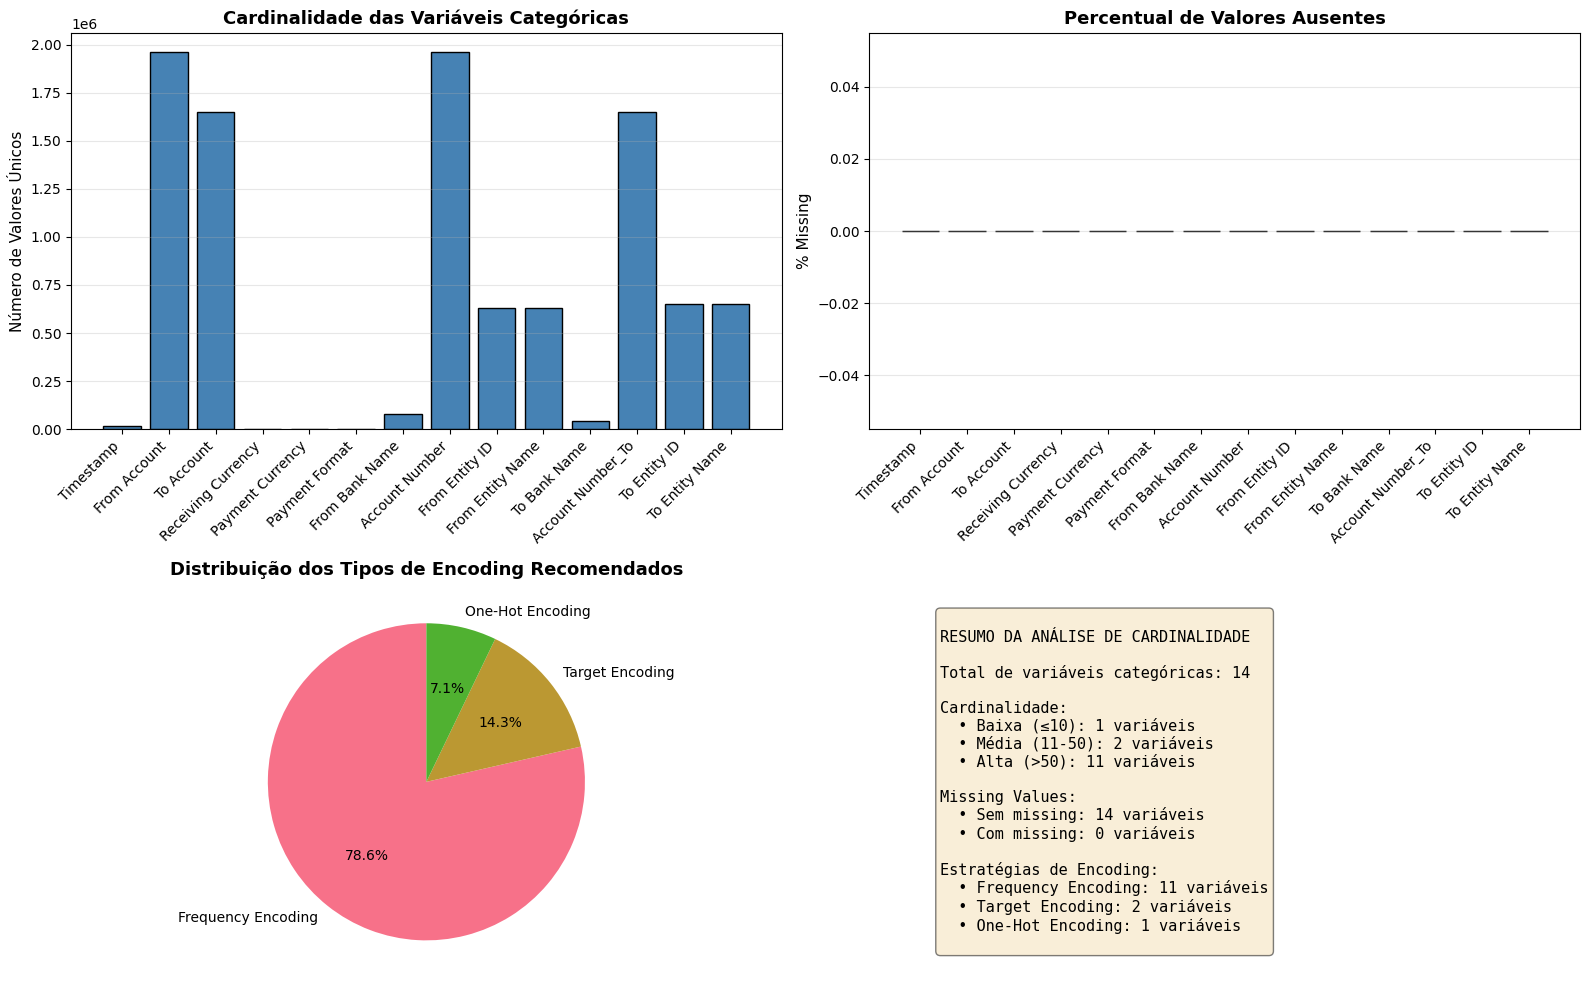

In [8]:
# Análise de cardinalidade
cardinality_analysis = []

for col in categorical_cols:
    n_unique = df_treino[col].nunique()
    n_missing = df_treino[col].isna().sum()
    pct_missing = (n_missing / len(df_treino)) * 100
    
    # Top 5 valores mais frequentes
    top_values = df_treino[col].value_counts().head(5)
    
    # Determinar tipo de encoding recomendado
    if n_unique == 2:
        encoding_type = "Binary/Label Encoding"
    elif n_unique <= 10:
        encoding_type = "One-Hot Encoding"
    elif n_unique <= 50:
        encoding_type = "Target Encoding"
    else:
        encoding_type = "Frequency Encoding"
    
    cardinality_analysis.append({
        'variable': col,
        'n_unique': n_unique,
        'n_missing': n_missing,
        'pct_missing': round(pct_missing, 2),
        'recommended_encoding': encoding_type,
        'top_value': top_values.index[0] if len(top_values) > 0 else None,
        'top_value_count': top_values.values[0] if len(top_values) > 0 else None
    })

df_cardinality = pd.DataFrame(cardinality_analysis)

print("="*80)
print("ANÁLISE DE CARDINALIDADE")
print("="*80)
print("\n", df_cardinality.to_string(index=False))

# Visualização
if len(df_cardinality) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Distribuição de cardinalidade
    axes[0, 0].bar(range(len(df_cardinality)), df_cardinality['n_unique'], color='steelblue', edgecolor='black')
    axes[0, 0].set_xticks(range(len(df_cardinality)))
    axes[0, 0].set_xticklabels(df_cardinality['variable'], rotation=45, ha='right')
    axes[0, 0].set_ylabel('Número de Valores Únicos', fontsize=11)
    axes[0, 0].set_title('Cardinalidade das Variáveis Categóricas', fontsize=13, fontweight='bold')
    axes[0, 0].grid(alpha=0.3, axis='y')
    
    # 2. Percentual de missing values
    axes[0, 1].bar(range(len(df_cardinality)), df_cardinality['pct_missing'], color='coral', edgecolor='black')
    axes[0, 1].set_xticks(range(len(df_cardinality)))
    axes[0, 1].set_xticklabels(df_cardinality['variable'], rotation=45, ha='right')
    axes[0, 1].set_ylabel('% Missing', fontsize=11)
    axes[0, 1].set_title('Percentual de Valores Ausentes', fontsize=13, fontweight='bold')
    axes[0, 1].grid(alpha=0.3, axis='y')
    
    # 3. Tipo de encoding recomendado
    encoding_counts = df_cardinality['recommended_encoding'].value_counts()
    axes[1, 0].pie(encoding_counts.values, labels=encoding_counts.index, autopct='%1.1f%%', startangle=90)
    axes[1, 0].set_title('Distribuição dos Tipos de Encoding Recomendados', fontsize=13, fontweight='bold')
    
    # 4. Tabela de resumo
    axes[1, 1].axis('off')
    summary_text = f"""
RESUMO DA ANÁLISE DE CARDINALIDADE

Total de variáveis categóricas: {len(categorical_cols)}

Cardinalidade:
  • Baixa (≤10): {(df_cardinality['n_unique'] <= 10).sum()} variáveis
  • Média (11-50): {((df_cardinality['n_unique'] > 10) & (df_cardinality['n_unique'] <= 50)).sum()} variáveis
  • Alta (>50): {(df_cardinality['n_unique'] > 50).sum()} variáveis

Missing Values:
  • Sem missing: {(df_cardinality['pct_missing'] == 0).sum()} variáveis
  • Com missing: {(df_cardinality['pct_missing'] > 0).sum()} variáveis

Estratégias de Encoding:
"""
    for enc_type, count in encoding_counts.items():
        summary_text += f"  • {enc_type}: {count} variáveis\n"
    
    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center', 
                    family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Nenhuma variável categórica encontrada!")

## 4. Feature Engineering - Variáveis Datetime

Extraindo features úteis das variáveis de data/tempo.

In [9]:
# Feature Engineering para variáveis datetime
def extract_datetime_features(df, datetime_cols, prefix=''):
    """
    Extrai features de variáveis datetime
    """
    df_copy = df.copy()
    
    for col in datetime_cols:
        if col in df_copy.columns:
            # Converter para datetime se necessário
            if df_copy[col].dtype != 'datetime64[ns]':
                df_copy[col] = pd.to_datetime(df_copy[col], errors='coerce')
            
            # Extrair componentes temporais
            df_copy[f'{col}_year'] = df_copy[col].dt.year
            df_copy[f'{col}_month'] = df_copy[col].dt.month
            df_copy[f'{col}_day'] = df_copy[col].dt.day
            df_copy[f'{col}_dayofweek'] = df_copy[col].dt.dayofweek  # 0=Monday, 6=Sunday
            df_copy[f'{col}_hour'] = df_copy[col].dt.hour
            df_copy[f'{col}_minute'] = df_copy[col].dt.minute
            df_copy[f'{col}_quarter'] = df_copy[col].dt.quarter
            df_copy[f'{col}_dayofyear'] = df_copy[col].dt.dayofyear
            df_copy[f'{col}_weekofyear'] = df_copy[col].dt.isocalendar().week
            
            # Features cíclicas (para capturar periodicidade)
            df_copy[f'{col}_month_sin'] = np.sin(2 * np.pi * df_copy[f'{col}_month'] / 12)
            df_copy[f'{col}_month_cos'] = np.cos(2 * np.pi * df_copy[f'{col}_month'] / 12)
            df_copy[f'{col}_dayofweek_sin'] = np.sin(2 * np.pi * df_copy[f'{col}_dayofweek'] / 7)
            df_copy[f'{col}_dayofweek_cos'] = np.cos(2 * np.pi * df_copy[f'{col}_dayofweek'] / 7)
            df_copy[f'{col}_hour_sin'] = np.sin(2 * np.pi * df_copy[f'{col}_hour'] / 24)
            df_copy[f'{col}_hour_cos'] = np.cos(2 * np.pi * df_copy[f'{col}_hour'] / 24)
            
            # Features de negócio (horários úteis, fim de semana, etc.)
            df_copy[f'{col}_is_weekend'] = df_copy[f'{col}_dayofweek'].isin([5, 6]).astype(int)
            df_copy[f'{col}_is_business_hours'] = df_copy[f'{col}_hour'].between(9, 17).astype(int)
            df_copy[f'{col}_is_night'] = (df_copy[f'{col}_hour'].between(22, 23) | df_copy[f'{col}_hour'].between(0, 5)).astype(int)
            
            print(f"✅ Features extraídas de '{col}': 19 novas variáveis")
    
    return df_copy

# Aplicar transformação apenas se houver variáveis datetime
if len(datetime_cols) > 0:
    print("Extraindo features de variáveis datetime...")
    print(f"Variáveis datetime: {datetime_cols}\n")
    
    df_treino = extract_datetime_features(df_treino, datetime_cols)
    df_oot = extract_datetime_features(df_oot, datetime_cols)
    
    print(f"\n✅ Shape após feature engineering temporal:")
    print(f"   Treino: {df_treino.shape}")
    print(f"   OOT: {df_oot.shape}")
else:
    print("⚠️ Nenhuma variável datetime encontrada.")

⚠️ Nenhuma variável datetime encontrada.


## 5. Encoding de Variáveis Categóricas

Aplicando diferentes técnicas de encoding baseadas na cardinalidade.

In [10]:
# Criar cópias para encoding
df_treino_encoded = df_treino.copy()
df_oot_encoded = df_oot.copy()

# Dicionário para armazenar encoders
encoders = {}

# Separar variáveis categóricas por tipo de encoding
binary_vars = []
onehot_vars = []
target_vars = []
frequency_vars = []

if len(df_cardinality) > 0:
    for idx, row in df_cardinality.iterrows():
        var = row['variable']
        n_unique = row['n_unique']
        
        if n_unique == 2:
            binary_vars.append(var)
        elif n_unique <= 10:
            onehot_vars.append(var)
        elif n_unique <= 50:
            target_vars.append(var)
        else:
            frequency_vars.append(var)

print("="*80)
print("ESTRATÉGIA DE ENCODING")
print("="*80)
print(f"\n📊 Binary/Label Encoding: {len(binary_vars)} variáveis")
if binary_vars:
    print(f"   {binary_vars}")
print(f"\n📊 One-Hot Encoding: {len(onehot_vars)} variáveis")
if onehot_vars:
    print(f"   {onehot_vars}")
print(f"\n📊 Target Encoding: {len(target_vars)} variáveis")
if target_vars:
    print(f"   {target_vars}")
print(f"\n📊 Frequency Encoding: {len(frequency_vars)} variáveis")
if frequency_vars:
    print(f"   {frequency_vars}")

ESTRATÉGIA DE ENCODING

📊 Binary/Label Encoding: 0 variáveis

📊 One-Hot Encoding: 1 variáveis
   ['Payment Format']

📊 Target Encoding: 2 variáveis
   ['Receiving Currency', 'Payment Currency']

📊 Frequency Encoding: 11 variáveis
   ['Timestamp', 'From Account', 'To Account', 'From Bank Name', 'Account Number', 'From Entity ID', 'From Entity Name', 'To Bank Name', 'Account Number_To', 'To Entity ID', 'To Entity Name']


### 5.1. Label Encoding (Variáveis Binárias)

Para variáveis com apenas 2 categorias, aplicamos Label Encoding simples (0 e 1).

In [11]:
# Label Encoding para variáveis binárias
if len(binary_vars) > 0:
    print("Aplicando Label Encoding em variáveis binárias...")
    
    for var in binary_vars:
        if var in df_treino_encoded.columns:
            # Criar encoder
            le = LabelEncoder()
            
            # Fit no treino
            df_treino_encoded[f'{var}_encoded'] = le.fit_transform(df_treino_encoded[var].astype(str))
            
            # Transform no OOT (tratar valores desconhecidos)
            oot_values = df_oot_encoded[var].astype(str)
            oot_encoded = []
            
            for val in oot_values:
                if val in le.classes_:
                    oot_encoded.append(le.transform([val])[0])
                else:
                    oot_encoded.append(-1)  # Valor desconhecido
            
            df_oot_encoded[f'{var}_encoded'] = oot_encoded
            
            # Armazenar encoder
            encoders[var] = {'type': 'label', 'encoder': le}
            
            print(f"   ✅ {var}: {le.classes_} → {list(range(len(le.classes_)))}")
    
    print(f"\n✅ Label Encoding concluído para {len(binary_vars)} variáveis!")
else:
    print("⚠️ Nenhuma variável binária encontrada.")

⚠️ Nenhuma variável binária encontrada.


### 5.2. One-Hot Encoding (Baixa Cardinalidade)

Para variáveis com 3 a 10 categorias, aplicamos One-Hot Encoding.

In [12]:
# One-Hot Encoding para variáveis de baixa cardinalidade
if len(onehot_vars) > 0:
    print("Aplicando One-Hot Encoding...")
    
    for var in onehot_vars:
        if var in df_treino_encoded.columns:
            # Get dummies no treino
            treino_dummies = pd.get_dummies(df_treino_encoded[var], prefix=var, drop_first=False)
            
            # Get dummies no OOT
            oot_dummies = pd.get_dummies(df_oot_encoded[var], prefix=var, drop_first=False)
            
            # Alinhar colunas (garantir que OOT tenha as mesmas colunas que treino)
            missing_cols = set(treino_dummies.columns) - set(oot_dummies.columns)
            for col in missing_cols:
                oot_dummies[col] = 0
            
            # Remover colunas extras no OOT
            oot_dummies = oot_dummies[treino_dummies.columns]
            
            # Adicionar ao dataframe
            df_treino_encoded = pd.concat([df_treino_encoded, treino_dummies], axis=1)
            df_oot_encoded = pd.concat([df_oot_encoded, oot_dummies], axis=1)
            
            # Armazenar info
            encoders[var] = {'type': 'onehot', 'columns': list(treino_dummies.columns)}
            
            print(f"   ✅ {var}: {len(treino_dummies.columns)} novas colunas criadas")
    
    print(f"\n✅ One-Hot Encoding concluído!")
    print(f"   Shape Treino: {df_treino_encoded.shape}")
    print(f"   Shape OOT: {df_oot_encoded.shape}")
else:
    print("⚠️ Nenhuma variável para One-Hot Encoding.")

Aplicando One-Hot Encoding...
   ✅ Payment Format: 7 novas colunas criadas

✅ One-Hot Encoding concluído!
   Shape Treino: (25001186, 28)
   Shape OOT: (6250297, 28)


### 5.3. Target Encoding (Média Cardinalidade)

Para variáveis com 11 a 50 categorias, aplicamos Target Encoding (média do target por categoria).

In [13]:
# Target Encoding para variáveis de média cardinalidade
if target_col and len(target_vars) > 0:
    print("Aplicando Target Encoding...")
    
    try:
        # Importar TargetEncoder
        from category_encoders import TargetEncoder
        
        for var in target_vars:
            if var in df_treino_encoded.columns:
                # Criar encoder
                te = TargetEncoder(smoothing=1.0, min_samples_leaf=10)
                
                # Fit e transform no treino
                df_treino_encoded[f'{var}_target_enc'] = te.fit_transform(
                    df_treino_encoded[var], 
                    df_treino_encoded[target_col]
                )
                
                # Transform no OOT
                df_oot_encoded[f'{var}_target_enc'] = te.transform(df_oot_encoded[var])
                
                # Armazenar encoder
                encoders[var] = {'type': 'target', 'encoder': te}
                
                print(f"   ✅ {var}: Target encoding aplicado")
        
        print(f"\n✅ Target Encoding concluído para {len(target_vars)} variáveis!")
    
    except ImportError:
        print("⚠️ Biblioteca 'category_encoders' não instalada.")
        print("   Aplicando Target Encoding manual...")
        
        for var in target_vars:
            if var in df_treino_encoded.columns:
                # Calcular média do target por categoria
                target_means = df_treino_encoded.groupby(var)[target_col].mean()
                global_mean = df_treino_encoded[target_col].mean()
                
                # Aplicar no treino
                df_treino_encoded[f'{var}_target_enc'] = df_treino_encoded[var].map(target_means)
                
                # Aplicar no OOT (usar média global para categorias desconhecidas)
                df_oot_encoded[f'{var}_target_enc'] = df_oot_encoded[var].map(target_means).fillna(global_mean)
                
                # Armazenar info
                encoders[var] = {'type': 'target_manual', 'mapping': target_means.to_dict(), 'global_mean': global_mean}
                
                print(f"   ✅ {var}: Target encoding manual aplicado")
        
        print(f"\n✅ Target Encoding manual concluído!")
else:
    print("⚠️ Target não disponível ou nenhuma variável para Target Encoding")

Aplicando Target Encoding...
   ✅ Receiving Currency: Target encoding aplicado
   ✅ Payment Currency: Target encoding aplicado

✅ Target Encoding concluído para 2 variáveis!


### 5.4. Frequency Encoding (Alta Cardinalidade)

Para variáveis com mais de 50 categorias, aplicamos Frequency Encoding (frequência de cada categoria).

In [14]:
# Frequency Encoding para variáveis de alta cardinalidade
if len(frequency_vars) > 0:
    print("Aplicando Frequency Encoding...")
    
    for var in frequency_vars:
        if var in df_treino_encoded.columns:
            # Calcular frequências no treino
            freq_map = df_treino_encoded[var].value_counts(normalize=True).to_dict()
            
            # Aplicar no treino
            df_treino_encoded[f'{var}_freq_enc'] = df_treino_encoded[var].map(freq_map)
            
            # Aplicar no OOT (usar 0 para categorias desconhecidas)
            df_oot_encoded[f'{var}_freq_enc'] = df_oot_encoded[var].map(freq_map).fillna(0)
            
            # Armazenar info
            encoders[var] = {'type': 'frequency', 'mapping': freq_map}
            
            print(f"   ✅ {var}: Frequency encoding aplicado")
    
    print(f"\n✅ Frequency Encoding concluído para {len(frequency_vars)} variáveis!")
else:
    print("⚠️ Nenhuma variável para Frequency Encoding.")

Aplicando Frequency Encoding...
   ✅ Timestamp: Frequency encoding aplicado
   ✅ From Account: Frequency encoding aplicado
   ✅ To Account: Frequency encoding aplicado
   ✅ From Bank Name: Frequency encoding aplicado
   ✅ Account Number: Frequency encoding aplicado
   ✅ From Entity ID: Frequency encoding aplicado
   ✅ From Entity Name: Frequency encoding aplicado
   ✅ To Bank Name: Frequency encoding aplicado
   ✅ Account Number_To: Frequency encoding aplicado
   ✅ To Entity ID: Frequency encoding aplicado
   ✅ To Entity Name: Frequency encoding aplicado

✅ Frequency Encoding concluído para 11 variáveis!


## 6. Tratamento de Valores Missing

Tratando valores ausentes nas variáveis codificadas.

In [15]:
# Verificar missing values
print("="*80)
print("ANÁLISE DE MISSING VALUES")
print("="*80)

missing_treino = df_treino_encoded.isna().sum()
missing_treino = missing_treino[missing_treino > 0].sort_values(ascending=False)

missing_oot = df_oot_encoded.isna().sum()
missing_oot = missing_oot[missing_oot > 0].sort_values(ascending=False)

print(f"\n📊 Treino - Variáveis com missing values: {len(missing_treino)}")
if len(missing_treino) > 0:
    print(missing_treino.head(20))

print(f"\n📊 OOT - Variáveis com missing values: {len(missing_oot)}")
if len(missing_oot) > 0:
    print(missing_oot.head(20))

# Estratégia de imputação
print("\n" + "="*80)
print("IMPUTAÇÃO DE VALORES MISSING")
print("="*80)

# Para variáveis numéricas: usar mediana
numeric_cols_current = df_treino_encoded.select_dtypes(include=[np.number]).columns

for col in numeric_cols_current:
    if df_treino_encoded[col].isna().sum() > 0:
        median_value = df_treino_encoded[col].median()
        df_treino_encoded[col].fillna(median_value, inplace=True)
        df_oot_encoded[col].fillna(median_value, inplace=True)
        print(f"   ✅ {col}: imputado com mediana ({median_value:.4f})")

print(f"\n✅ Imputação concluída!")
print(f"   Missing no treino: {df_treino_encoded.isna().sum().sum()}")
print(f"   Missing no OOT: {df_oot_encoded.isna().sum().sum()}")

ANÁLISE DE MISSING VALUES

📊 Treino - Variáveis com missing values: 0

📊 OOT - Variáveis com missing values: 0

IMPUTAÇÃO DE VALORES MISSING

✅ Imputação concluída!
   Missing no treino: 0
   Missing no OOT: 0


## 7. Remoção de Variáveis Originais

Removendo as variáveis categóricas e datetime originais, mantendo apenas as versões codificadas.

In [16]:
# Identificar colunas a serem removidas
cols_to_remove = []

# Adicionar variáveis categóricas originais
cols_to_remove.extend([col for col in categorical_cols if col in df_treino_encoded.columns])

# Adicionar variáveis datetime originais (mas manter features extraídas)
cols_to_remove.extend([col for col in datetime_cols if col in df_treino_encoded.columns])

print("="*80)
print("REMOÇÃO DE COLUNAS ORIGINAIS")
print("="*80)
print(f"\n📊 Colunas a serem removidas: {len(cols_to_remove)}")
if cols_to_remove:
    print(f"\n{cols_to_remove}")

# Remover colunas
df_treino_final = df_treino_encoded.drop(columns=cols_to_remove, errors='ignore')
df_oot_final = df_oot_encoded.drop(columns=cols_to_remove, errors='ignore')

print(f"\n✅ Colunas removidas!")
print(f"\n📊 Shape final:")
print(f"   Treino: {df_treino_encoded.shape} → {df_treino_final.shape}")
print(f"   OOT: {df_oot_encoded.shape} → {df_oot_final.shape}")

REMOÇÃO DE COLUNAS ORIGINAIS

📊 Colunas a serem removidas: 14

['Timestamp', 'From Account', 'To Account', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'From Bank Name', 'Account Number', 'From Entity ID', 'From Entity Name', 'To Bank Name', 'Account Number_To', 'To Entity ID', 'To Entity Name']

✅ Colunas removidas!

📊 Shape final:
   Treino: (25001186, 41) → (25001186, 27)
   OOT: (6250297, 41) → (6250297, 27)


## 8. Verificação Final dos Dados

Verificando a qualidade e consistência dos dados finais.

In [17]:
# Verificação final
print("="*80)
print("VERIFICAÇÃO FINAL DOS DADOS")
print("="*80)

print(f"\n📊 Dataset de Treino:")
print(f"   Shape: {df_treino_final.shape}")
print(f"   Colunas: {len(df_treino_final.columns)}")
print(f"   Linhas: {len(df_treino_final):,}")
print(f"   Missing values: {df_treino_final.isna().sum().sum()}")
print(f"   Memória: {df_treino_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📊 Dataset OOT:")
print(f"   Shape: {df_oot_final.shape}")
print(f"   Colunas: {len(df_oot_final.columns)}")
print(f"   Linhas: {len(df_oot_final):,}")
print(f"   Missing values: {df_oot_final.isna().sum().sum()}")
print(f"   Memória: {df_oot_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n📋 Tipos de dados finais:")
print(df_treino_final.dtypes.value_counts())

print(f"\n📊 Estatísticas descritivas (primeiras 10 colunas):")
df_treino_final.iloc[:, :10].describe()

VERIFICAÇÃO FINAL DOS DADOS

📊 Dataset de Treino:
   Shape: (25001186, 27)
   Colunas: 27
   Linhas: 25,001,186
   Missing values: 0
   Memória: 3981.78 MB

📊 Dataset OOT:
   Shape: (6250297, 27)
   Colunas: 27
   Linhas: 6,250,297
   Missing values: 0
   Memória: 1037.17 MB

📋 Tipos de dados finais:
float64    19
bool        7
int64       1
Name: count, dtype: int64

📊 Estatísticas descritivas (primeiras 10 colunas):


,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Bank ID,Bank ID_To
count,25001186.000000,25001186.000000,25001186.000000,25001186.000000,25001186.000000,25001186.000000,25001186.000000
mean,21.116621,40.122922,6.371034,6.395076,0.000490,21.116621,40.122922
std,10.412189,15.913810,2.470695,2.478043,0.022137,10.412189,15.913810
min,0.000000,0.000000,0.000001,0.000001,0.000000,0.000000,0.000000
25%,13.242042,29.270076,4.799382,4.816868,0.000000,13.242042,29.270076
50%,21.961174,40.848900,6.372789,6.396118,0.000000,21.961174,40.848900
75%,28.217966,45.685512,7.940091,7.969872,0.000000,28.217966,45.685512
max,42.474836,75.244506,17.634178,17.838715,1.000000,42.474836,75.244506



DISTRIBUIÇÃO DA VARIÁVEL TARGET

📊 Treino:
Is Laundering
0    24988928
1       12258
Name: count, dtype: int64

Proporção:
Is Laundering
0   0.999510
1   0.000490
Name: proportion, dtype: float64

📊 OOT:
Is Laundering
0    6246514
1       3783
Name: count, dtype: int64

Proporção:
Is Laundering
0   0.999395
1   0.000605
Name: proportion, dtype: float64


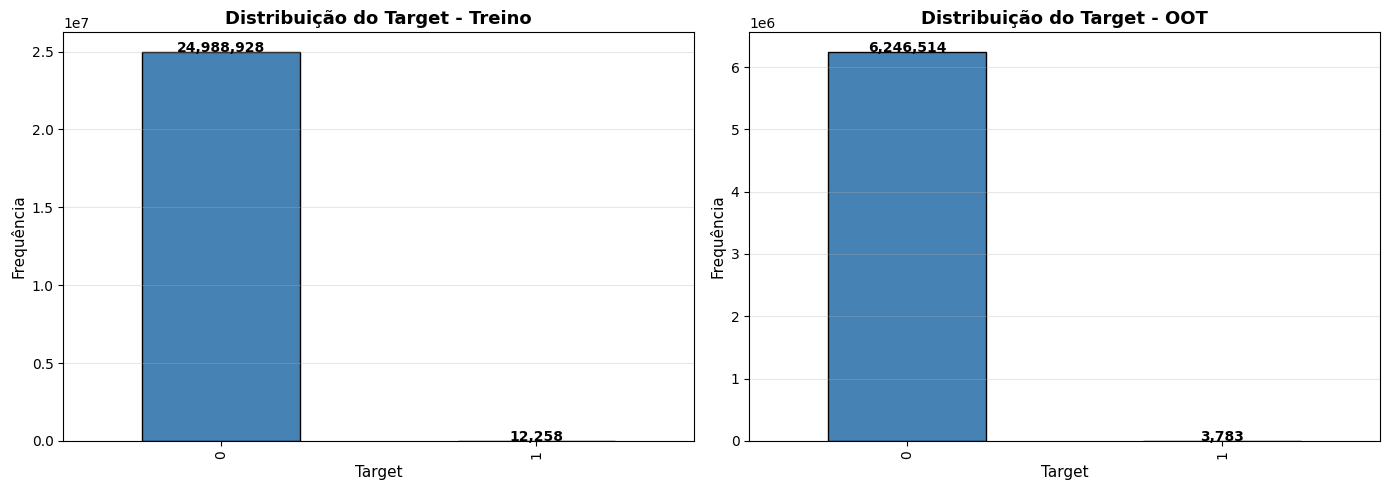

In [18]:
# Verificar se target existe e sua distribuição
if target_col and target_col in df_treino_final.columns:
    print("\n" + "="*80)
    print("DISTRIBUIÇÃO DA VARIÁVEL TARGET")
    print("="*80)
    
    print(f"\n📊 Treino:")
    print(df_treino_final[target_col].value_counts())
    print(f"\nProporção:")
    print(df_treino_final[target_col].value_counts(normalize=True))
    
    print(f"\n📊 OOT:")
    print(df_oot_final[target_col].value_counts())
    print(f"\nProporção:")
    print(df_oot_final[target_col].value_counts(normalize=True))
    
    # Visualização
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Treino
    df_treino_final[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
    axes[0].set_title('Distribuição do Target - Treino', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Target', fontsize=11)
    axes[0].set_ylabel('Frequência', fontsize=11)
    axes[0].grid(alpha=0.3, axis='y')
    for i, v in enumerate(df_treino_final[target_col].value_counts()):
        axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
    
    # OOT
    df_oot_final[target_col].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='black')
    axes[1].set_title('Distribuição do Target - OOT', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Target', fontsize=11)
    axes[1].set_ylabel('Frequência', fontsize=11)
    axes[1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(df_oot_final[target_col].value_counts()):
        axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ Variável target não encontrada nos dados finais.")

## 9. Separação de Features e Target

Preparando os dados para modelagem: separando features (X) e target (y).

In [19]:
# Separar features e target
if target_col and target_col in df_treino_final.columns:
    # Identificar colunas de features (excluindo target e possíveis IDs)
    id_cols = ['id', 'ID', 'Id', 'account_id', 'AccountID', 'transaction_id', 'TransactionID']
    cols_to_exclude = [target_col] + [col for col in id_cols if col in df_treino_final.columns]
    
    feature_cols_final = [col for col in df_treino_final.columns if col not in cols_to_exclude]
    
    # Treino
    X_train = df_treino_final[feature_cols_final].copy()
    y_train = df_treino_final[target_col].copy()
    
    # OOT
    X_oot = df_oot_final[feature_cols_final].copy()
    y_oot = df_oot_final[target_col].copy()
    
    print("="*80)
    print("SEPARAÇÃO FEATURES E TARGET")
    print("="*80)
    
    print(f"\n📊 Treino:")
    print(f"   X_train shape: {X_train.shape}")
    print(f"   y_train shape: {y_train.shape}")
    print(f"   Features: {len(feature_cols_final)}")
    
    print(f"\n📊 OOT:")
    print(f"   X_oot shape: {X_oot.shape}")
    print(f"   y_oot shape: {y_oot.shape}")
    
    print(f"\n📋 Primeiras features:")
    for i, col in enumerate(feature_cols_final[:20], 1):
        print(f"   {i}. {col}")
    
    if len(feature_cols_final) > 20:
        print(f"   ... e mais {len(feature_cols_final) - 20} features")
    
    # Verificar tipos de dados
    print(f"\n📊 Tipos de dados das features:")
    print(X_train.dtypes.value_counts())
    
    # Verificar se há apenas valores numéricos
    non_numeric = X_train.select_dtypes(exclude=[np.number]).columns
    if len(non_numeric) > 0:
        print(f"\n⚠️ ATENÇÃO: {len(non_numeric)} features não-numéricas encontradas:")
        print(f"   {list(non_numeric)}")
    else:
        print(f"\n✅ Todas as features são numéricas!")
else:
    print("⚠️ Target não disponível. Mantendo dataset completo.")
    X_train = df_treino_final.copy()
    X_oot = df_oot_final.copy()

SEPARAÇÃO FEATURES E TARGET

📊 Treino:
   X_train shape: (25001186, 26)
   y_train shape: (25001186,)
   Features: 26

📊 OOT:
   X_oot shape: (6250297, 26)
   y_oot shape: (6250297,)

📋 Primeiras features:
   1. From Bank
   2. To Bank
   3. Amount Received
   4. Amount Paid
   5. Bank ID
   6. Bank ID_To
   7. Payment Format_ACH
   8. Payment Format_Bitcoin
   9. Payment Format_Cash
   10. Payment Format_Cheque
   11. Payment Format_Credit Card
   12. Payment Format_Reinvestment
   13. Payment Format_Wire
   14. Receiving Currency_target_enc
   15. Payment Currency_target_enc
   16. Timestamp_freq_enc
   17. From Account_freq_enc
   18. To Account_freq_enc
   19. From Bank Name_freq_enc
   20. Account Number_freq_enc
   ... e mais 6 features

📊 Tipos de dados das features:
float64    19
bool        7
Name: count, dtype: int64

⚠️ ATENÇÃO: 7 features não-numéricas encontradas:
   ['Payment Format_ACH', 'Payment Format_Bitcoin', 'Payment Format_Cash', 'Payment Format_Cheque', 'Payment F

## 10. Exportação dos Dados Finais

Salvando os datasets processados e prontos para treinamento.

In [20]:
# Exportar dados finais
import os
import json

output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

print("="*80)
print("EXPORTAÇÃO DOS DADOS FINAIS")
print("="*80)

# 1. Datasets completos (com target)
treino_final_path = os.path.join(output_dir, 'df_treino_final.csv')
oot_final_path = os.path.join(output_dir, 'df_oot_final.csv')

print(f"\n📁 Salvando datasets completos...")
df_treino_final.to_csv(treino_final_path, index=False)
df_oot_final.to_csv(oot_final_path, index=False)
print(f"   ✅ {treino_final_path}")
print(f"   ✅ {oot_final_path}")

# 2. Features separadas (X)
if 'X_train' in locals():
    X_train_path = os.path.join(output_dir, 'X_train.csv')
    X_oot_path = os.path.join(output_dir, 'X_oot.csv')
    
    print(f"\n📁 Salvando features (X)...")
    X_train.to_csv(X_train_path, index=False)
    X_oot.to_csv(X_oot_path, index=False)
    print(f"   ✅ {X_train_path}")
    print(f"   ✅ {X_oot_path}")

# 3. Target separado (y)
if 'y_train' in locals():
    y_train_path = os.path.join(output_dir, 'y_train.csv')
    y_oot_path = os.path.join(output_dir, 'y_oot.csv')
    
    print(f"\n📁 Salvando target (y)...")
    y_train.to_csv(y_train_path, index=False, header=True)
    y_oot.to_csv(y_oot_path, index=False, header=True)
    print(f"   ✅ {y_train_path}")
    print(f"   ✅ {y_oot_path}")

# 4. Informações sobre as transformações
transformations_info = {
    'datetime_features_extracted': datetime_cols,
    'categorical_encoding': {
        'binary_vars': binary_vars,
        'onehot_vars': onehot_vars,
        'target_vars': target_vars,
        'frequency_vars': frequency_vars
    },
    'total_features': len(feature_cols_final) if 'feature_cols_final' in locals() else len(df_treino_final.columns),
    'target_column': target_col,
    'encoding_summary': {}
}

for var, info in encoders.items():
    transformations_info['encoding_summary'][var] = {
        'type': info['type'],
        'details': f"{info['type']} applied"
    }

transformations_path = os.path.join(output_dir, 'feature_engineering_info.json')
with open(transformations_path, 'w') as f:
    json.dump(transformations_info, f, indent=4)

print(f"\n📁 Salvando informações sobre transformações...")
print(f"   ✅ {transformations_path}")

# 5. Lista de features
if 'feature_cols_final' in locals():
    features_list_path = os.path.join(output_dir, 'feature_list.txt')
    with open(features_list_path, 'w') as f:
        for col in feature_cols_final:
            f.write(f"{col}\n")
    print(f"\n📁 Salvando lista de features...")
    print(f"   ✅ {features_list_path}")

print("\n" + "="*80)
print("✅ EXPORTAÇÃO CONCLUÍDA COM SUCESSO!")
print("="*80)

EXPORTAÇÃO DOS DADOS FINAIS

📁 Salvando datasets completos...
   ✅ ../data/processed\df_treino_final.csv
   ✅ ../data/processed\df_oot_final.csv

📁 Salvando features (X)...
   ✅ ../data/processed\X_train.csv
   ✅ ../data/processed\X_oot.csv

📁 Salvando target (y)...
   ✅ ../data/processed\y_train.csv
   ✅ ../data/processed\y_oot.csv

📁 Salvando informações sobre transformações...
   ✅ ../data/processed\feature_engineering_info.json

📁 Salvando lista de features...
   ✅ ../data/processed\feature_list.txt

✅ EXPORTAÇÃO CONCLUÍDA COM SUCESSO!


In [21]:
# Verificar tamanhos dos arquivos
print("="*80)
print("RESUMO DOS ARQUIVOS GERADOS")
print("="*80)

for filename in ['df_treino_final.csv', 'df_oot_final.csv', 'X_train.csv', 'X_oot.csv', 
                 'y_train.csv', 'y_oot.csv', 'feature_engineering_info.json', 'feature_list.txt']:
    filepath = os.path.join(output_dir, filename)
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"\n✅ {filename}")
        print(f"   Tamanho: {size_mb:.2f} MB")

print("\n" + "="*80)

RESUMO DOS ARQUIVOS GERADOS

✅ df_treino_final.csv
   Tamanho: 10531.67 MB

✅ df_oot_final.csv
   Tamanho: 2091.38 MB

✅ X_train.csv
   Tamanho: 10483.98 MB

✅ X_oot.csv
   Tamanho: 2079.45 MB

✅ y_train.csv
   Tamanho: 71.53 MB

✅ y_oot.csv
   Tamanho: 17.88 MB

✅ feature_engineering_info.json
   Tamanho: 0.00 MB

✅ feature_list.txt
   Tamanho: 0.00 MB



## 11. Resumo Executivo

Resumo completo de todo o processo de engenharia de atributos.

In [22]:
# Resumo Executivo Final
print("="*80)
print("RESUMO EXECUTIVO - ENGENHARIA DE ATRIBUTOS")
print("="*80)

print(f"\n1. DADOS ORIGINAIS:")
print(f"   - Treino: {df_treino.shape}")
print(f"   - OOT: {df_oot.shape}")

print(f"\n2. VARIÁVEIS PROCESSADAS:")
print(f"   - Variáveis categóricas: {len(categorical_cols)}")
print(f"   - Variáveis datetime: {len(datetime_cols)}")
print(f"   - Variáveis numéricas: {len(numeric_cols)}")

print(f"\n3. ENCODING APLICADO:")
print(f"   - Label Encoding (binárias): {len(binary_vars)} variáveis")
print(f"   - One-Hot Encoding (baixa card.): {len(onehot_vars)} variáveis")
print(f"   - Target Encoding (média card.): {len(target_vars)} variáveis")
print(f"   - Frequency Encoding (alta card.): {len(frequency_vars)} variáveis")

if len(datetime_cols) > 0:
    print(f"\n4. FEATURE ENGINEERING TEMPORAL:")
    print(f"   - {len(datetime_cols)} variáveis datetime processadas")
    print(f"   - ~19 features extraídas por variável datetime")
    print(f"   - Features: ano, mês, dia, dia da semana, hora, minuto, trimestre")
    print(f"   - Features cíclicas: sin/cos para mês, dia da semana, hora")
    print(f"   - Features de negócio: fim de semana, horário comercial, noturno")

print(f"\n5. DADOS FINAIS PARA TREINAMENTO:")
if 'X_train' in locals():
    print(f"   - X_train: {X_train.shape}")
    print(f"   - y_train: {y_train.shape}")
    print(f"   - X_oot: {X_oot.shape}")
    print(f"   - y_oot: {y_oot.shape}")
    print(f"   - Total de features: {X_train.shape[1]}")
else:
    print(f"   - Treino: {df_treino_final.shape}")
    print(f"   - OOT: {df_oot_final.shape}")

print(f"\n6. QUALIDADE DOS DADOS:")
print(f"   - Missing values (treino): {df_treino_final.isna().sum().sum()}")
print(f"   - Missing values (OOT): {df_oot_final.isna().sum().sum()}")
if 'X_train' in locals() and len(X_train.select_dtypes(exclude=[np.number]).columns) == 0:
    print(f"   ✅ Todas as features são numéricas")
else:
    print(f"   ⚠️ Verificar features não-numéricas")

print(f"\n7. ARQUIVOS GERADOS:")
print(f"   - df_treino_final.csv: Dataset completo de treino")
print(f"   - df_oot_final.csv: Dataset completo OOT")
print(f"   - X_train.csv: Features de treino")
print(f"   - y_train.csv: Target de treino")
print(f"   - X_oot.csv: Features OOT")
print(f"   - y_oot.csv: Target OOT")
print(f"   - feature_engineering_info.json: Informações das transformações")
print(f"   - feature_list.txt: Lista de todas as features")

print(f"\n8. PRÓXIMOS PASSOS:")
print(f"   ✅ Dados prontos para treinamento de modelos")
print(f"   ✅ Considerar feature selection se necessário")
print(f"   ✅ Aplicar normalização/padronização se o modelo exigir")
print(f"   ✅ Treinar modelos de Machine Learning")
print(f"   ✅ Avaliar performance no conjunto OOT")

print("\n" + "="*80)
print("✅ ENGENHARIA DE ATRIBUTOS CONCLUÍDA COM SUCESSO!")
print("="*80)

RESUMO EXECUTIVO - ENGENHARIA DE ATRIBUTOS

1. DADOS ORIGINAIS:
   - Treino: (25001186, 21)
   - OOT: (6250297, 21)

2. VARIÁVEIS PROCESSADAS:
   - Variáveis categóricas: 14
   - Variáveis datetime: 0
   - Variáveis numéricas: 7

3. ENCODING APLICADO:
   - Label Encoding (binárias): 0 variáveis
   - One-Hot Encoding (baixa card.): 1 variáveis
   - Target Encoding (média card.): 2 variáveis
   - Frequency Encoding (alta card.): 11 variáveis

5. DADOS FINAIS PARA TREINAMENTO:
   - X_train: (25001186, 26)
   - y_train: (25001186,)
   - X_oot: (6250297, 26)
   - y_oot: (6250297,)
   - Total de features: 26

6. QUALIDADE DOS DADOS:
   - Missing values (treino): 0
   - Missing values (OOT): 0
   ⚠️ Verificar features não-numéricas

7. ARQUIVOS GERADOS:
   - df_treino_final.csv: Dataset completo de treino
   - df_oot_final.csv: Dataset completo OOT
   - X_train.csv: Features de treino
   - y_train.csv: Target de treino
   - X_oot.csv: Features OOT
   - y_oot.csv: Target OOT
   - feature_engin